In [5]:
import pandas as pd

url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE64nnn/GSE64216/matrix/GSE64216_series_matrix.txt.gz"

df = pd.read_csv(
    url,
    sep="\t",
    comment="!",
    index_col=0
)

print("Main dataset loaded.")
print(df.shape)

df.head()

Main dataset loaded.
(47323, 8)


,GSM1566477,GSM1566478,GSM1566479,GSM1566480,GSM1566481,GSM1566482,GSM1566483,GSM1566484
ID_REF,,,,,,,,
ILMN_1343291,15455.180000,16948.840000,15668.810000,16627.360000,15430.970000,14870.660000,16627.360000,16819.040000
ILMN_1343295,2744.761000,3101.433000,4262.785000,2992.852000,2428.143000,3768.169000,4704.884000,2791.899000
ILMN_1651199,-5.074675,-5.580920,-8.899057,-2.783093,1.164959,-5.628981,-9.311296,-4.303506
ILMN_1651209,11.902830,9.970214,9.240218,16.964080,3.334404,11.472300,8.148111,10.610310
ILMN_1651210,-4.392920,0.458118,-0.773564,-0.563690,-2.977006,0.894042,2.656628,-4.077556


In [2]:
import pandas as pd
import gzip
import io
import requests

url = "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPL10nnn/GPL10558/annot/GPL10558.annot.gz"

# Download file
response = requests.get(url)

# Open gzip
with gzip.open(io.BytesIO(response.content), 'rt') as f:
    lines = f.readlines()

# Find start and end of platform table
start = None
end = None

for i, line in enumerate(lines):
    if "!platform_table_begin" in line:
        start = i + 1
    if "!platform_table_end" in line:
        end = i
        break

# Read only table part
table_data = "".join(lines[start:end])

annot = pd.read_csv(
    io.StringIO(table_data),
    sep="\t"
)

print("Annotation loaded successfully")

print("Columns:")
print(annot.columns)

annot.head()

Annotation loaded successfully
Columns:
Index(['ID', 'Gene title', 'Gene symbol', 'Gene ID', 'UniGene title',
       'UniGene symbol', 'UniGene ID', 'Nucleotide Title', 'GI',
       'GenBank Accession', 'Platform_CLONEID', 'Platform_ORF',
       'Platform_SPOTID', 'Chromosome location', 'Chromosome annotation',
       'GO:Function', 'GO:Process', 'GO:Component', 'GO:Function ID',
       'GO:Process ID', 'GO:Component ID', 'Platform_SEQUENCE'],
      dtype='object')


,ID,Gene title,Gene symbol,Gene ID,UniGene title,UniGene symbol,UniGene ID,Nucleotide Title,GI,GenBank Accession,...,Platform_SPOTID,Chromosome location,Chromosome annotation,GO:Function,GO:Process,GO:Component,GO:Function ID,GO:Process ID,GO:Component ID,Platform_SEQUENCE
0,ILMN_1343048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GAATAAAGAACAATCTGCTGATGATCCCTCCGTGGATCTGATTCGT...
1,ILMN_1343049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CCATGTGATACGAGGGCGCGTAGTTTGCATTATCGTTTTTATCGTT...
2,ILMN_1343050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CCGACAGATGTATGTAAGGCCAACGTGCTCAAATCTTCATACAGAA...
3,ILMN_1343052,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCTGTCACTGTCAGGAAAGTGGTAAAACTGCAACTCAATTACTGCA...
4,ILMN_1343059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CTTGTGCCTGAGCTGTCAAAAGTAGAGCACGTCGCCGAGATGAAGG...


In [ ]:
mapping = annot[
    ["ID", "Gene symbol"]
].dropna()

print("Mapping shape:", mapping.shape)

mapping.head()

Mapping shape: (31266, 2)


,ID,Gene symbol
9,ILMN_1343291,EEF1A1
10,ILMN_1343295,GAPDH
782,ILMN_1651209,SLC35E2
783,ILMN_1651210,DUSP22
785,ILMN_1651228,RPS28


In [ ]:
deg = deg.merge(
    mapping,
    left_on="Gene",
    right_on="ID",
    how="left"
)

print("Merge completed")

deg.head()

Merge completed


,Gene,log2FC,p_value,Gene_upper,ID,Gene symbol
0,ILMN_1343291,-0.026324,0.767898,ILMN_1343291,ILMN_1343291,EEF1A1
1,ILMN_1343295,0.143064,0.638876,ILMN_1343295,ILMN_1343295,GAPDH
2,ILMN_1651199,-0.788402,0.597639,ILMN_1651199,NaN,NaN
3,ILMN_1651209,-0.138188,0.811232,ILMN_1651209,ILMN_1651209,SLC35E2
4,ILMN_1651210,-1.142897,0.864797,ILMN_1651210,ILMN_1651210,DUSP22


In [ ]:
ferro_genes = [
"ACSL1","ACSL3","ACSL4","ACSL5",
"ALOX15","ATG5","ATG7",
"CP","CYBB","FTH1",
"FTL","GCLC","GCLM",
"GPX4","HMOX1",
"SLC7A11","TFRC","TP53"
]

deg["Gene_upper"] = deg["Gene symbol"].astype(str).str.upper()

ferro_deg = deg[
    deg["Gene_upper"].isin(ferro_genes)
]

print("Ferroptosis-related genes found:", len(ferro_deg))

Ferroptosis-related genes found: 32


In [ ]:
ferro_deg_sig = ferro_deg[
    ferro_deg["p_value"] < 0.05
]

print("Significant ferroptosis genes:", len(ferro_deg_sig))

ferro_deg_sig.head(10)

Significant ferroptosis genes: 0


,Gene,log2FC,p_value,Gene_upper,ID,Gene symbol


In [ ]:
ferro_deg_sig = ferro_deg[
    ferro_deg["p_value"] < 0.1
]

print("Significant ferroptosis genes:", len(ferro_deg_sig))

ferro_deg_sig.head(10)

Significant ferroptosis genes: 1


,Gene,log2FC,p_value,Gene_upper,ID,Gene symbol
13285,ILMN_1718265,-0.195074,0.079388,ATG5,ILMN_1718265,ATG5


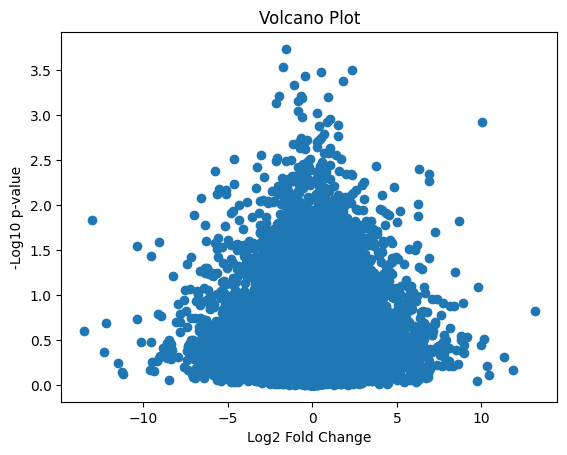

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

plt.scatter(
deg["log2FC"],
-np.log10(deg["p_value"])
)

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 p-value")
plt.title("Volcano Plot")

plt.show()

In [3]:
# Save annotation dataset to Excel

annot.to_excel(
    "GPL10558_annotation_dataset.xlsx",
    index=False
)

print("Annotation dataset saved as Excel file.")

Annotation dataset saved as Excel file.


In [6]:
df.to_excel(
    "GSE64216_expression_dataset.xlsx"
)

from google.colab import files
files.download("GSE64216_expression_dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>